In [1]:
# %pip -q install sentence-transformers ruptures yake syntok

In [2]:
# !pip install -q opencv-python

In [3]:
import os
import time
from datetime import datetime, timedelta

In [4]:
import re, numpy as np, ruptures as rpt
from skimage.metrics import structural_similarity as ssim
from syntok.segmenter import segment

In [5]:
import cv2
import logging

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')s

In [7]:
# %cd /content/drive/MyDrive/AIO/Video2Doc/AIO

In [8]:
%cd /Users/tuantrinh/Documents/AIO2025/video-to-doc-generator/

/Users/tuantrinh/Documents/AIO2025/video-to-doc-generator


In [9]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('slide_detection.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

In [10]:
def calculate_histogram_similarity(frame1: np.ndarray, frame2: np.ndarray) -> float:
    """Calculate histogram similarity between two frames."""
    try:
        # Convert to grayscale for histogram comparison
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

        # Calculate histograms
        hist1 = cv2.calcHist([gray1], [0], None, [256], [0, 256])
        hist2 = cv2.calcHist([gray2], [0], None, [256], [0, 256])

        # Normalize histograms
        hist1 = cv2.normalize(hist1, hist1).flatten()
        hist2 = cv2.normalize(hist2, hist2).flatten()

        # Calculate correlation
        similarity = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
        return similarity

    except Exception as e:
        logger.error(f"Error calculating histogram similarity: {e}")
        return 0.0

In [11]:
def calculate_ssim(frame1: np.ndarray, frame2: np.ndarray) -> float:
        """Calculate Structural Similarity Index between two frames."""
        try:
            # Convert to grayscale
            gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
            gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

            # Resize frames to same size for comparison
            height, width = gray1.shape
            gray2_resized = cv2.resize(gray2, (width, height))

            # Calculate SSIM using scikit-image
            try:
                ssim_score = ssim(gray1, gray2_resized, data_range=255)
                return ssim_score
            except ImportError:
                # Fallback to histogram comparison if scikit-image not available
                logger.warning(
                    "scikit-image not available, using histogram comparison instead")
                return self.calculate_histogram_similarity(frame1, frame2)

        except Exception as e:
            logger.error(f"Error calculating SSIM: {e}")
            # Fallback to histogram comparison
            return calculate_histogram_similarity(frame1, frame2)

In [38]:
def segment_video(novelty_s, frames,  model="rbf", pen=10, min_len = 6):
    algo = rpt.Pelt(model=model).fit(novelty_s)
    bkps = algo.predict(pen= pen)  # thử 10–20; tăng giảm để được số đoạn mong muốn
    print(bkps)
    # 6) Áp min segment length & tạo đoạn
    filtered = []
    prev = 0
    for b in bkps:
        if b - prev < min_len:  # quá ngắn -> bỏ ranh giới này
            continue
        filtered.append(b)
        prev = b
    bkps = filtered

    segments = []
    start = 0
    for b in bkps:
        segments.append((start, b))
        start = b
    if start < frames:
        segments.append((start, frames))
    return segments

In [33]:
def moving_average(novelty, k=50):
    # 4) Làm trơn (moving average)
    kernel = np.ones(k)/k
    return np.convolve(novelty, kernel, mode='same')

In [35]:
def process_video(video_path: str, output_path: str = None):
    """
    Process video file and detect slide changes.

    Args:
        video_path: Path to input video file
        output_path: Path for output JSON file (optional)

    Returns:
        List of detected slide changes
    """
    print(video_path)
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")

    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}")

    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    print(f"Processing video: {video_path}")
    print(f"FPS: {fps:.2f}, Total frames: {total_frames},Duration: {duration/60:.2f} minutes")

    # Reset state
    slide_changes = []
    current_slide_number = 0
    previous_frame = None

    frame_count = 0
    start_time = time.time()
    ssim_scores = []
    hist_scores = []

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # Removed the condition to break after 3000 frames
            if frame_count < 24000:
                # print(frame_count)
                frame_count += 1
                continue
            if previous_frame is None:
                previous_frame = frame.copy()
                ssim_scores.append(1)
                hist_scores.append(1)
            else:
                if frame_count % 25 == 0:
                  ssim_score = calculate_ssim(previous_frame, frame)
                  hist_score = calculate_histogram_similarity(previous_frame, frame)
                  ssim_scores.append(ssim_score)
                  hist_scores.append(hist_score)
                  previous_frame = frame.copy()
                  print(f' scoring:{ssim_score}, {hist_score}')

            frame_count += 1

            # Progress update every 1000 frames
            if frame_count % 1000 == 0:
                elapsed = time.time() - start_time
                progress = (frame_count / total_frames) * 100
                print(f"Progress: {progress:.1f}% ({frame_count}/{total_frames}")
                print(f"Elapsed: {elapsed:.1f}s")

    finally:
        cap.release()
    novelty_s = np.array([ssim_scores, hist_scores]).T
    # algo = rpt.Pelt(model="rbf").fit(novelty_s)
    # bkps = algo.predict(pen= 10)  # thử 10–20; tăng giảm để được số đoạn mong muốn
    # print(bkps)
    # # Add final slide if video ends
    # if self.current_slide_number == 0:
    #     # No changes detected, add initial slide
    #     self.slide_changes.append({
    #         "timestamp": "00:00:00",
    #         "timestamp_seconds": 0.0,
    #         "frame_number": 0,
    #         "slide_number": 1,
    #         "description": "Slide 1 (Initial)"
    #     })

    # # Save results
    # if output_path:
    #     self.save_results(output_path)

    # logger.info(
    #     f"Processing complete. Detected {len(self.slide_changes)} slide changes")
    return novelty_s,frame_count

In [25]:
ls

Documents_2025-7_M03W02 - K Nearest Neighbor (KNN)_AIO2025_KNN.pdf
README.md
example_slide_changes.json
generated/
requirements.txt
run.bat
sentence-segmentaion/
slide-detector/
slide-detector copy/
slide_detection.log
whisper/


In [ ]:
video_path = 'slide-detector copy/M03W02 - K Nearest Neighbor (KNN).mp4'
novelty_s,frame_count = process_video(video_path)

slide-detector copy/M03W02 - K Nearest Neighbor (KNN).mp4
Processing video: slide-detector copy/M03W02 - K Nearest Neighbor (KNN).mp4
FPS: 25.00, Total frames: 320814,Duration: 213.88 minutes
 scoring:1.0, 1.0
 scoring:0.478031828985643, 0.07522709297699105
 scoring:0.9026658115731598, 0.9964046419190759
 scoring:0.9807191396950431, 0.9998093573303806
 scoring:0.9730600246565205, 0.9994671077481968
 scoring:0.8935152390776911, 0.9983168160058414
 scoring:0.822871283787135, 0.995160523985671
 scoring:0.8425089204058765, 0.9980497077758123
 scoring:0.8368535032515548, 0.9941123576235548
 scoring:0.8563318784860978, 0.9962484114116532
 scoring:0.8786484152535664, 0.9992526526303985
 scoring:0.8897119636079428, 0.9988057062692828
 scoring:0.8980067417541349, 0.9988545286375415
 scoring:0.8832611396451475, 0.9991051387781317
 scoring:0.8528429775764076, 0.9976264201523721
 scoring:0.8771094470203004, 0.9985699754304037
 scoring:0.8550476717237848, 0.9965609914447442
 scoring:0.8600625432683

In [ ]:
# frame_count = 320814
segmentation = segment_video(novelty_s[:,0], frame_count, pen = 5, min_len = 6)
print(segmentation)

[45, 230, 270, 360, 1060, 2350, 2585, 2690, 3805, 4465, 4505, 6075, 6555, 6645, 6885, 6925, 6955, 7185, 7220, 7405, 7945, 7965, 7980, 8030, 8055, 9095, 9145, 9730, 9855, 10560, 10810, 10930, 11310, 11350, 11775, 11845, 11873]
[(0, 45), (45, 230), (230, 270), (270, 360), (360, 1060), (1060, 2350), (2350, 2585), (2585, 2690), (2690, 3805), (3805, 4465), (4465, 4505), (4505, 6075), (6075, 6555), (6555, 6645), (6645, 6885), (6885, 6925), (6925, 6955), (6955, 7185), (7185, 7220), (7220, 7405), (7405, 7945), (7945, 7965), (7965, 7980), (7980, 8030), (8030, 8055), (8055, 9095), (9095, 9145), (9145, 9730), (9730, 9855), (9855, 10560), (10560, 10810), (10810, 10930), (10930, 11310), (11310, 11350), (11350, 11775), (11775, 11845), (11845, 11873), (11873, 320814)]


In [27]:
novelty_s[:,1]

array([1.        , 1.        , 0.07522709, ..., 1.        , 1.        ,
       1.        ], shape=(11873,))

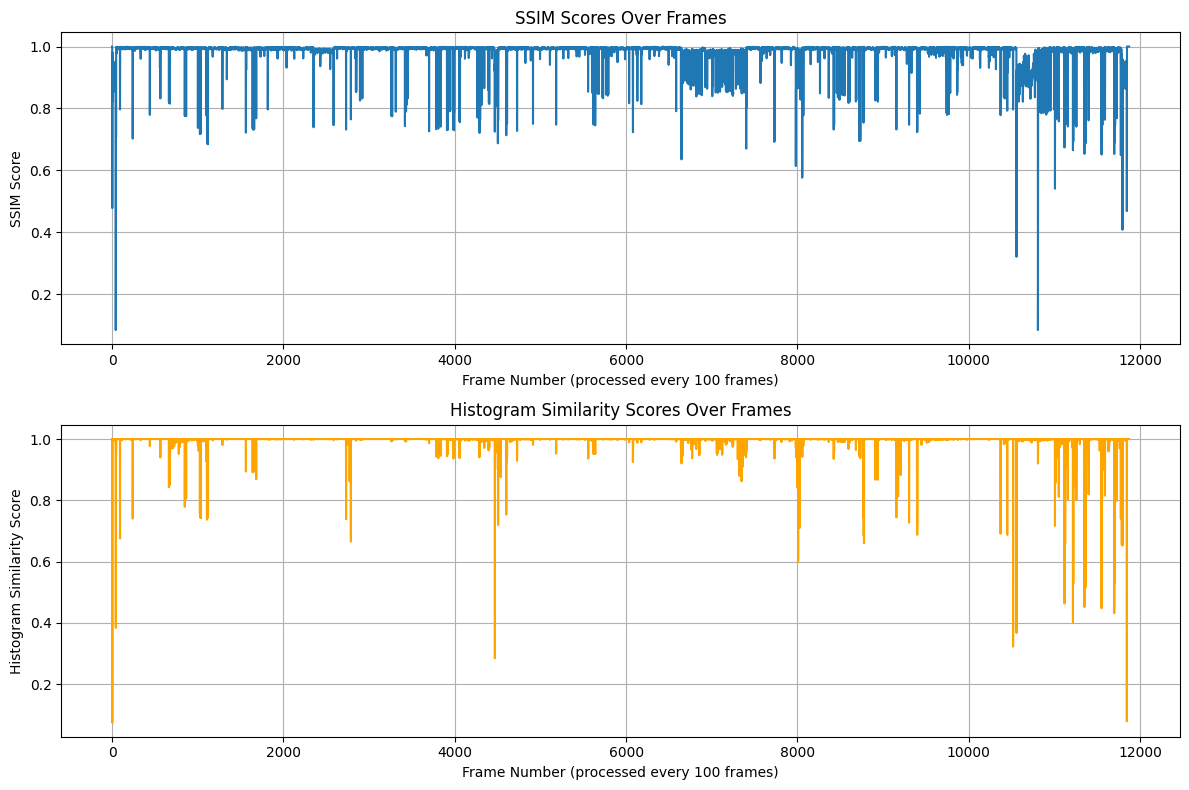

In [ ]:
import matplotlib.pyplot as plt

# Assuming ssim_scores and hist_scores are available from the previous cell execution
# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot ssim_scores in the first subplot
axes[0].plot(novelty_s[:,0])
axes[0].set_title('SSIM Scores Over Frames')
axes[0].set_xlabel('Frame Number (processed every 100 frames)')
axes[0].set_ylabel('SSIM Score')
axes[0].grid(True)

# Plot hist_scores in the second subplot
axes[1].plot(novelty_s[:,1], color='orange')
axes[1].set_title('Histogram Similarity Scores Over Frames')
axes[1].set_xlabel('Frame Number (processed every 100 frames)')
axes[1].set_ylabel('Histogram Similarity Score')
axes[1].grid(True)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()